# Inside the solver

`contrailopt` treats trajectory optimization as a [shortest path problem](https://en.wikipedia.org/wiki/Shortest_path_problem). It builds a finite **directed acyclic graph** of candidate waypoints, determines the cost of every edge in kilograms of fuel, and solves it by dynamic programming.

This notebook builds that graph for a single origin-destination pair and animates the solver's search across it. For simplicity, the contrail term is excluded here so the cost function involves only fuel and time.

In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import contrailopt as co

## Flight

A westbound transcontinental flight, into the jet stream.

In [2]:
origin = co.AirportCoords.from_icao("KBOS")
dest = co.AirportCoords.from_icao("KSEA")

aircraft_type = "B737"
takeoff_time = pd.Timestamp("2026-03-01")

## Weather

Temperature and winds come from the public [ARCO-ERA5](https://github.com/google-research/arco-era5) archive.

In [3]:
data_vars = {
    "temperature": "air_temperature",
    "u_component_of_wind": "eastward_wind",
    "v_component_of_wind": "northward_wind",
}

arco_store = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"
arco_ds = xr.open_zarr(arco_store, chunks=None)

met = arco_ds[list(data_vars)].rename(data_vars)

## Building the graph

**Nodes.** Points are randomly sampled within a corridor along the great circle between the origin and destination. We use Poisson-disk sampling, which enforces a minimum separation, so the corridor is covered without clumps or holes.

> The nodes are random points, not published navigation fixes, so a route through this graph is not something an airline could file as-is.

**Edges.** A directed edge $T \to H$ is formed between a tail node $T$ and a head node $H$ when four conditions hold:

- The distance between the nodes is under `max_dist_m` (500 km by default).
- The bearing $T \to H$ is within `max_angle_deg` (40° by default) of the bearing from $T$ to the destination, so the edge points roughly toward the destination.
- The bearing $H \to T$ is within `max_angle_deg` of the bearing from $H$ to the origin, so the edge points roughly away from the origin.
- The progress score strictly increases from $T$ to $H$, where a node's score is its distance from the origin minus its distance to the destination.

The last condition is what makes the graph [acyclic](https://en.wikipedia.org/wiki/Directed_acyclic_graph): a cycle would have to return to the progress score it started from.

A final pass prunes the graph further, trimming edges from high-degree nodes and dropping any node that cannot lie on a route from the origin to the destination.

In [4]:
opt = co.Optimizer(
    origin_icao=origin,
    dest_icao=dest,
    takeoff_time=takeoff_time,
    aircraft_type=aircraft_type,
    met=met,
    rng=np.random.default_rng(1234),  # reproducibility
)

opt

Optimizer(KBOS -> KSEA, B737, 2026-03-01 00:00:00, 453 nodes, with met, unsolved)

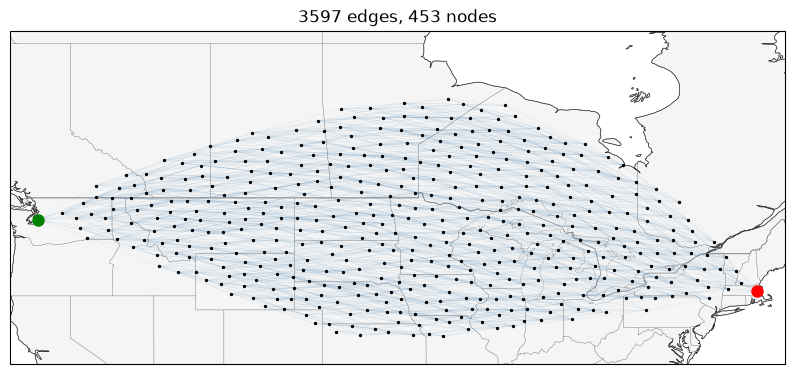

In [5]:
ax = opt.dag.plot(linewidth=0.2)
ax.get_figure().set_size_inches(10, 6)

## The dynamic program

The search operates on states: a node together with a cruise flight level. Each state records the cost of the cheapest path found to it, along with that path's arrival mass, elapsed time, incoming Mach number, and a backpointer to the previous state.

Every edge out of a state is priced over each combination of two actions:

- The flight level at the head of the edge (here FL280 to FL400 in increments of 2000 ft), with any change flown as a step climb or descent
- The Mach number held across the edge (here 0.75 to 0.81 in increments of 0.01)

That is 49 candidates per edge for this flight. Only the cheapest Mach is retained per flight level, so Mach is an action rather than a dimension of the state.

Because the graph is acyclic, nodes are processed in topological wavefronts ([Kahn's algorithm](https://en.wikipedia.org/wiki/Topological_sorting#Kahn's_algorithm)): wavefront *k* holds the nodes whose in-degree drops to zero once wavefronts 0 through *k−1* are removed. A whole wavefront is processed at once, so the costs of all its outgoing edges are computed with `numpy` operations rather than one node at a time.

The cost of an edge is the fuel burned to fly it (from the Poll-Schumann model) plus its elapsed time priced through the cost index in kg per minute. Fuel burn depends on aircraft mass and mass depends on fuel loaded, so the `solve` method sweeps across the graph several times, each time reloading the takeoff mass from the trip fuel of the previous sweep.

> The cost of an edge depends on the state at its tail: a heavier aircraft burns more fuel. Cost is therefore not additive over edges in the way a shortest path problem requires. We simplify by keeping one path per state, the cheapest, and carrying its mass along to price the next edge. Mass never enters the comparison, so a path arriving slightly more expensive but lighter is discarded even when it would have won later. Keeping the full Pareto front over cost and mass would remove the approximation at a cost in memory and speed.

In [6]:
res = opt.solve(cost_index=30)

print(f"takeoff mass {res.amass_init:.0f} kg")
print(f"trip fuel    {res.trip_fuel:.0f} kg")

takeoff mass 66246 kg
trip fuel    13667 kg


## Animate the solve

The `animate_solve` method re-runs the dynamic program with the converged takeoff mass, recording a snapshot per wavefront. Nodes are colored by their best cost at that moment, and edges light up once their source node has been processed. Only a single flight level is shown at once. The final frames walk the backpointers from the destination to reveal the optimal path.

In [7]:
gif_path = "../_static/wavefront.gif"

anim = opt.animate_solve()
anim.save(gif_path, writer="pillow", fps=8, dpi=50)
plt.close("all")

![Wavefront sweep across the DAG](../_static/wavefront.gif)

## The trajectory

As demonstrated in the second half of the animation above, the `to_flight` method follows the backpointers from the destination back to the origin and expands each edge into waypoints, interpolating the climb, cruise, and descent along the way. The result is an ordinary `pycontrails.Flight`.

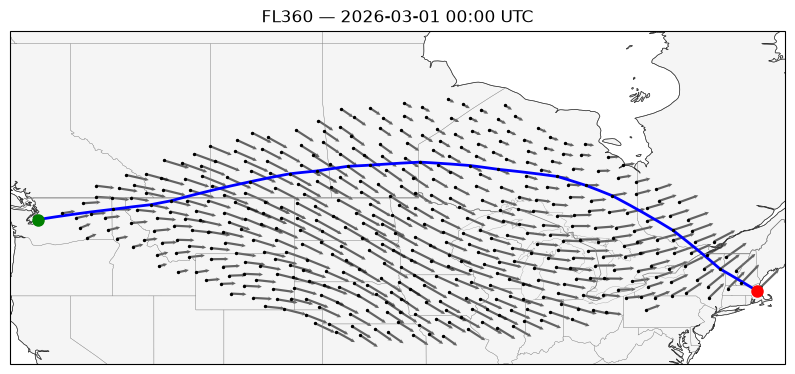

In [8]:
fl = opt.to_flight()

ax = opt.plot_met(altitude_ft=36000)
ax.plot(
    fl["longitude"],
    fl["latitude"],
    transform=ccrs.PlateCarree(),
    linewidth=2,
    color="blue",
)
ax.get_figure().set_size_inches(10, 6)